# **Titanic Dataset Visualization Dashboard**

## **1.Objective** 
This notebook performs data cleaning, simple feature engineering, exploratory data analysis (EDA), and creates a mini dashboard using different visualization techniques to understand the Titanic dataset.

## **2. Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

## **3. Load Dataset**

In [ ]:
df = pd.read_csv("train.csv")
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## **4. Data Cleaning**

In [ ]:

df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df.drop(columns=["Cabin"], inplace=True, errors="ignore")

## **5. Feature Engineering**

In [ ]:
df["FamilySize"] = df["SibSp"] + df["Parch"]
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0,12,18,35,60,100],
    labels=["Child","Teen","Young Adult","Adult","Senior"]
)

Dashboard
## **Chart 1 - Histogram**

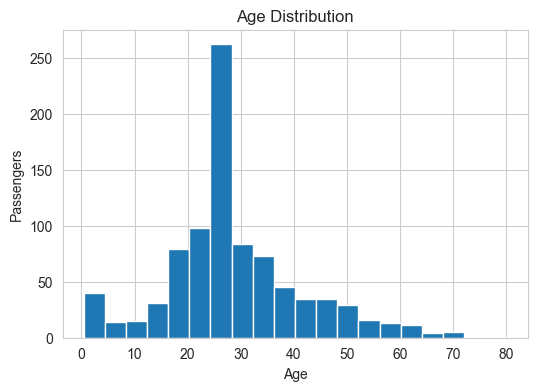

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(df["Age"], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Passengers")
plt.show()

- Most passengers were between 20–40 years, indicating that adults formed the majority of travelers.

## **Chart 2 - Bar Chart**

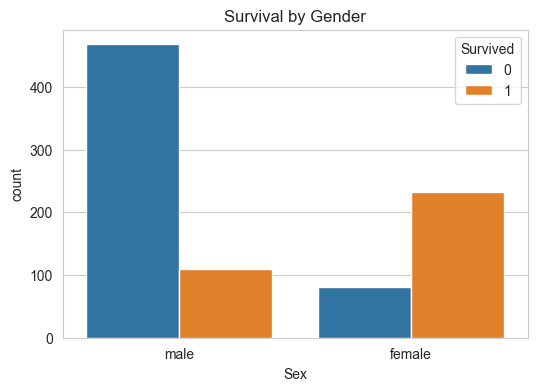

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Survival by Gender")
plt.show()

- Female passengers had a much higher survival rate than male passengers.

## **Chart 3 - Boxplot**

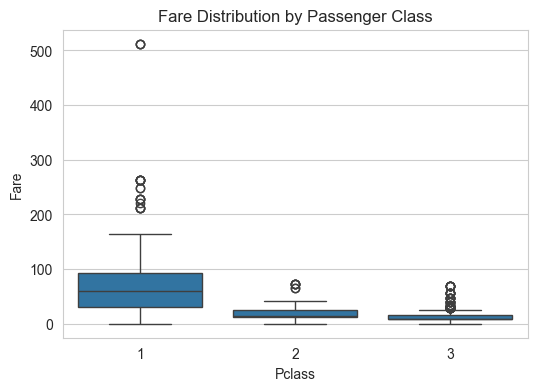

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Pclass", y="Fare", data=df)
plt.title("Fare Distribution by Passenger Class")
plt.show()

- First-class passengers generally paid higher fares, with several fare outliers.

## **Chart 4 - Scatter Plot**

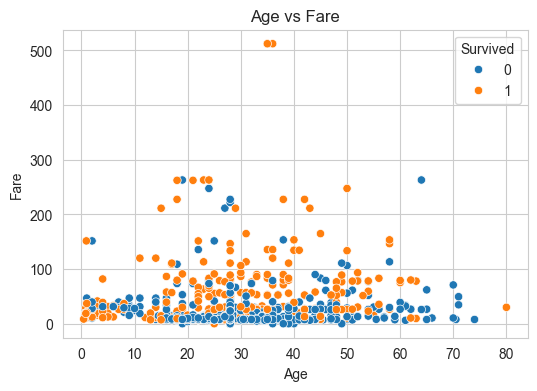

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="Age", y="Fare", hue="Survived", data=df)
plt.title("Age vs Fare")
plt.show()

- Passengers paying higher fares showed a greater chance of survival.

## **Chart 5 - Heatmap**

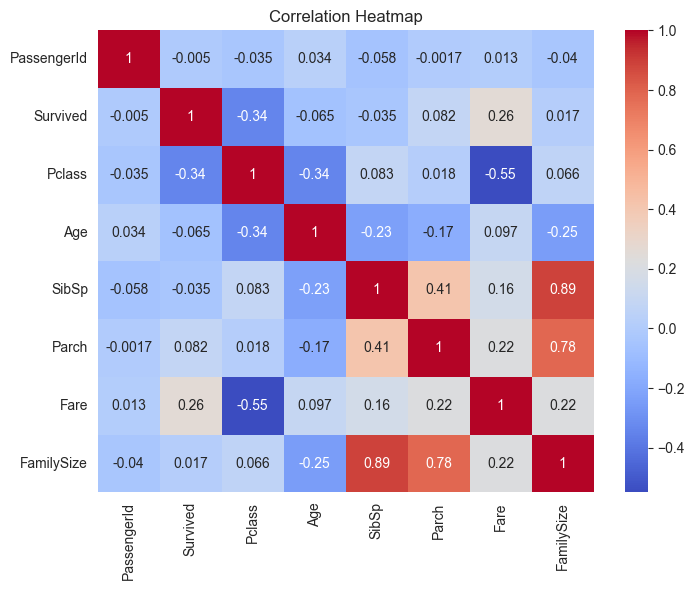

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

- Fare is positively correlated with survival, while passenger class is negatively correlated with survival.

## **Conclusion** 

- Most passengers were adults.
- Female passengers had the highest survival rate.
- Higher ticket fares were associated with better survival chances.
- First-class passengers generally paid higher fares.
- The dashboard provides useful insights into passenger demographics and survival patterns.